In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math

In [2]:
df=pd.read_csv('nhanes_2015_2016.csv')

In [3]:
df.head()

,SEQN,ALQ101,ALQ110,ALQ130,SMQ020,RIAGENDR,RIDAGEYR,RIDRETH1,DMDCITZN,DMDEDUC2,...,BPXSY2,BPXDI2,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,BMXWAIST,HIQ210
0,83732,1.0,NaN,1.0,1,1,62,3,1.0,5.0,...,124.0,64.0,94.8,184.5,27.8,43.3,43.6,35.9,101.1,2.0
1,83733,1.0,NaN,6.0,1,1,53,3,2.0,3.0,...,140.0,88.0,90.4,171.4,30.8,38.0,40.0,33.2,107.9,NaN
2,83734,1.0,NaN,NaN,1,1,78,3,1.0,3.0,...,132.0,44.0,83.4,170.1,28.8,35.6,37.0,31.0,116.5,2.0
3,83735,2.0,1.0,1.0,2,2,56,3,1.0,5.0,...,134.0,68.0,109.8,160.9,42.4,38.5,37.7,38.3,110.1,2.0
4,83736,2.0,1.0,1.0,2,2,42,4,1.0,4.0,...,114.0,54.0,55.2,164.9,20.3,37.4,36.0,27.2,80.4,2.0


## Question 1

Relabel the marital status variable [DMDMARTL](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#DMDMARTL) to have brief but informative character labels.  Then construct a frequency table of these values for all people, then for women only and for men only.  Then construct these three frequency tables using only people whose age is between 30 and 40.

In [4]:
r = {1: "Married", 2: "Widowed", 3: "Divorced", 4: "Separated", 5: "NeverMarried", 6: "Cohabitating", 77: "Refused", 99: "Unknown"}
df["DMDMARTLx"] = df["DMDMARTL"].replace(r)

In [5]:
print("All Subject")
x=df['DMDMARTLx'].value_counts()  # maritial status
print(x/x.sum())

All Subject
DMDMARTLx
Married         0.507855
NeverMarried    0.183412
Divorced        0.105773
Cohabitating    0.096273
Widowed         0.072342
Separated       0.033979
Refused         0.000365
Name: count, dtype: float64


In [6]:
df['RIAGENDRx']=df['RIAGENDR'].replace({1:"Male",2:"Female"})
print('All Gender')
y=df['RIAGENDRx'].value_counts()
print(y/y.sum())

All Gender
RIAGENDRx
Female    0.518919
Male      0.481081
Name: count, dtype: float64


In [7]:
for ky,db in df.groupby("RIAGENDRx"):
    print("\nRIAGENDR=",ky)
    x=db['DMDMARTLx'].value_counts()
    print(x/x.sum())


RIAGENDR= Female
DMDMARTLx
Married         0.457193
NeverMarried    0.182456
Divorced        0.122807
Widowed         0.103860
Cohabitating    0.091930
Separated       0.041404
Refused         0.000351
Name: count, dtype: float64

RIAGENDR= Male
DMDMARTLx
Married         0.562881
NeverMarried    0.184451
Cohabitating    0.100991
Divorced        0.087271
Widowed         0.038110
Separated       0.025915
Refused         0.000381
Name: count, dtype: float64


In [8]:
da3040=df.query('RIDAGEYR>=30 & RIDAGEYR<=40')
for ky,db in da3040.groupby('RIAGENDRx'):
    print('\nRIAGENDR=',ky,'30<=RIDAGEYR<=40')
    x=db['DMDMARTLx'].value_counts()
    print(x/x.sum())


RIAGENDR= Female 30<=RIDAGEYR<=40
DMDMARTLx
Married         0.535714
NeverMarried    0.218045
Cohabitating    0.122180
Divorced        0.086466
Separated       0.033835
Widowed         0.003759
Name: count, dtype: float64

RIAGENDR= Male 30<=RIDAGEYR<=40
DMDMARTLx
Married         0.556680
NeverMarried    0.204453
Cohabitating    0.157895
Divorced        0.048583
Separated       0.024291
Widowed         0.006073
Refused         0.002024
Name: count, dtype: float64


__Q1a.__ Briefly comment on some of the differences that you observe between the distribution of marital status between women and men, for people of all ages.

Compared to men, women have a lower probability of being currently married, a greater probability of being divorced, and a much greater probability of being widowed compared to men.

__Q1b.__ Briefly comment on the differences that you observe between the distribution of marital status states for women between the overall population, and for women between the ages of 30 and 40.

Women between the ages of 30 and 40 have a much lower probability of being widowed, a lower probability of being divorced, and a greater probability of cohabitating, compared to women of all ages.

__Q1c.__ Repeat part b for the men.

Men between the ages of 30 and 40 have a greater probability of cohabitating, a lower probability of being divorced, and a much lower probability of being widowed, compared to men of all ages.

## Question 2

Restricting to the female population, stratify the subjects into age bands no wider than ten years, and construct the distribution of marital status within each age band.  Within each age band, present the distribution in terms of proportions that must sum to 1.

In [9]:
# restrict the dataset to female only
da_mod=df.query("RIAGENDR==2").copy()
# calculate the minimum and maximum ages
minage=min(da_mod['RIDAGEYR'])
maxage=max(da_mod['RIDAGEYR'])


In [10]:
# one way to create the list of bins so that the first bin is closed on the left
bins = [minage] + list(range(int(math.ceil(minage/10)) * 10, int(math.ceil(maxage/10)) * 10, 10)) + [maxage]

# another way to create the list of bins without using the math library
# bins = [18, 20, 30, 40, 50, 60, 70, 80]
#print(bins)

# create labels for the bins
labels = [f"({bins[i]}, {bins[i+1]}]" if(i) else f"[{bins[i]}, {bins[i+1]}]" for i in range(len(bins)-1)]

# create the agegrp "bins" variable
da_mod["agegrp"] = pd.cut(da_mod.RIDAGEYR, bins, labels=labels, include_lowest = True)

# what does agegroup look like?
#print(da_mod.agegrp.value_counts(dropna=False))

# what does DMDMARTLx look like? Any rare or missing values?
#print(da_mod.DMDMARTLx.value_counts(dropna=False))

# distribution of marital status
dx = da_mod.loc[~da_mod.DMDMARTLx.isin(["Refused", np.nan]), :]  # drop rare/missing values
dx = dx.groupby(["agegrp"])["DMDMARTLx"]
dx = dx.value_counts()
dx = dx.unstack() # Restructure the results from 'long' to 'wide'
dx = dx.apply(lambda x: x/x.sum(), axis=1) # Normalize within each stratum to get proportions
print("Females")
print(dx.to_string(float_format="%.3f"))  # Limit display to 3 decimal places

# alternative that replaces NaN with 0
#print(dx.fillna(0).to_string(float_format="%.3f"))

Females
DMDMARTLx  Cohabitating  Divorced  Married  NeverMarried  Separated  Widowed
agegrp                                                                      
[18, 20]          0.205       NaN    0.026         0.769        NaN      NaN
(20, 30]          0.206     0.021    0.305         0.446      0.021      NaN
(30, 40]          0.120     0.091    0.544         0.205      0.036    0.004
(40, 50]          0.074     0.137    0.574         0.125      0.066    0.024
(50, 60]          0.068     0.177    0.548         0.090      0.058    0.060
(60, 70]          0.043     0.193    0.481         0.086      0.050    0.147
(70, 80]          0.007     0.144    0.317         0.051      0.020    0.461


__Q2a.__ Comment on the trends that you see in this series of marginal distributions.

##### 1. Cohabitating
* it is most common among younger adults and declines with age
* Around 2-4% of female under 30 are cohabiting

##### 2. Divorced
* divorced is rare among the youngest females(at age 18-30)
* it increases age age increases for 30-70 
* it decrease approx 5% after 70

##### 3. Married
* married rate increases as age for 18-60
* married rate decreases after age 60-80

##### 4. NeverMarried
* Never married decreases sharply with age
* it is at peak for age group 18-20 

##### 5. Separated
* separation increases for age group 20-50
* most female separated at age group 40-50 i.e 6%

##### 6. Widowed
* it is absent for age group 18-30
* it increases with age group
* it is peak at age group 70-80



__Q2b.__ Repeat the analysis for males.

In [11]:
# restrict the dataset to male only
da_mod=df.query("RIAGENDR==1").copy()
# calculate the minimum and maximum ages
minage=min(da_mod['RIDAGEYR'])
maxage=max(da_mod['RIDAGEYR'])


In [12]:
# one way to create the list of bins so that the first bin is closed on the left
bins = [minage] + list(range(int(math.ceil(minage/10)) * 10, int(math.ceil(maxage/10)) * 10, 10)) + [maxage]

# another way to create the list of bins without using the math library
# bins = [18, 20, 30, 40, 50, 60, 70, 80]
#print(bins)

# create labels for the bins
labels = [f"({bins[i]}, {bins[i+1]}]" if(i) else f"[{bins[i]}, {bins[i+1]}]" for i in range(len(bins)-1)]

# create the agegrp "bins" variable
da_mod["agegrp"] = pd.cut(da_mod.RIDAGEYR, bins, labels=labels, include_lowest = True)

# what does agegroup look like?
#print(da_mod.agegrp.value_counts(dropna=False))

# what does DMDMARTLx look like? Any rare or missing values?
#print(da_mod.DMDMARTLx.value_counts(dropna=False))

# distribution of marital status
dx = da_mod.loc[~da_mod.DMDMARTLx.isin(["Refused", np.nan]), :]  # drop rare/missing values
dx = dx.groupby(["agegrp"])["DMDMARTLx"]
dx = dx.value_counts()
dx = dx.unstack() # Restructure the results from 'long' to 'wide'
dx = dx.apply(lambda x: x/x.sum(), axis=1) # Normalize within each stratum to get proportions
print("males")
print(dx.to_string(float_format="%.3f"))  # Limit display to 3 decimal places

# alternative that replaces NaN with 0
#print(dx.fillna(0).to_string(float_format="%.3f"))

males
DMDMARTLx  Cohabitating  Divorced  Married  NeverMarried  Separated  Widowed
agegrp                                                                      
[18, 20]          0.075       NaN    0.025         0.900        NaN      NaN
(20, 30]          0.213     0.005    0.238         0.523      0.016    0.005
(30, 40]          0.158     0.053    0.565         0.195      0.026    0.004
(40, 50]          0.082     0.085    0.703         0.097      0.027    0.005
(50, 60]          0.075     0.126    0.652         0.104      0.022    0.022
(60, 70]          0.050     0.126    0.666         0.087      0.032    0.039
(70, 80]          0.022     0.142    0.612         0.022      0.035    0.167


##### 1. Cohabitating
* it is peak for age group 20-30 i.e 21%
* it is decreasing significantly as age decline

##### 2. Divorced
* divorce is peak at age group 70-80 
* divorce increases age increases 
* it is lowest at age 18-20

##### 3. Married
* married rate increases as age increase
* married rate is highest at age 40-50
* married rate decreases after age 60-80

##### 4. NeverMarried
* Never married decreases sharply with age
* it is at peak for age group 18-20 

##### 5. Separated
* separation increases for age group 20-50
* most male separated at age group 70-80

##### 6. Widowed
* it is absent for age group 18-30
* it increases with age group
* it is peak at age group 70-80



__Q2c.__ Comment on any notable differences that you see when comparing these results between females and for males.

## Question 3

Construct a histogram of the distribution of heights using the BMXHT variable in the NHANES sample.

<Axes: xlabel='BMXHT', ylabel='Count'>

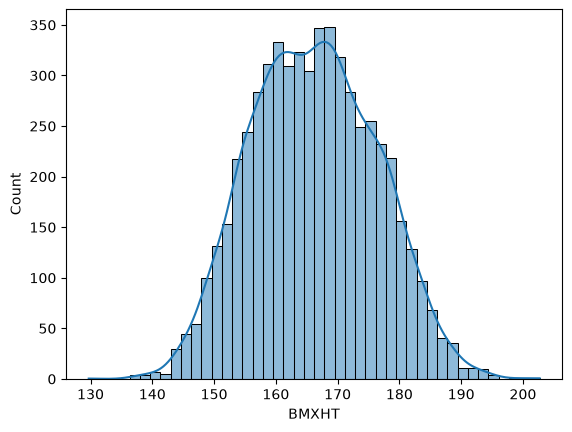

In [14]:
sns.histplot(x=df['BMXHT'],kde=True)

__Q3a.__ Use the `bins` argument to [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot) to produce histograms with different numbers of bins.  Assess whether the default value for this argument gives a meaningful result, and comment on what happens as the number of bins grows excessively large or excessively small. 

<Axes: xlabel='BMXHT', ylabel='Count'>

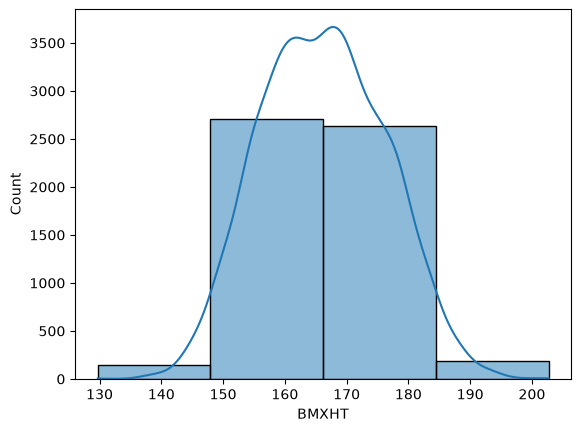

In [16]:
# bins=4
sns.histplot(df['BMXHT'],bins=4,kde=True)

<Axes: xlabel='BMXHT', ylabel='Count'>

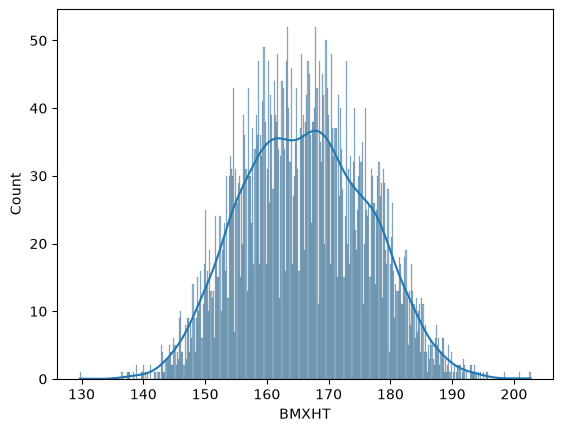

In [17]:
# bins=400
sns.histplot(df['BMXHT'],bins=400,kde=True)

__Q3b.__ Make separate histograms for the heights of women and men, then make a side-by-side boxplot showing the heights of women and men.

<Axes: xlabel='BMXHT', ylabel='Count'>

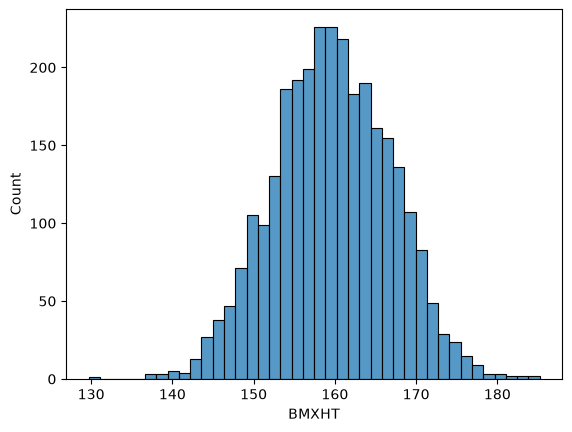

In [26]:
# histogram of female BMXHT
fem_hei=df.query('RIAGENDR==2')
sns.histplot(data=fem_hei.BMXHT)

<Axes: xlabel='BMXHT', ylabel='Count'>

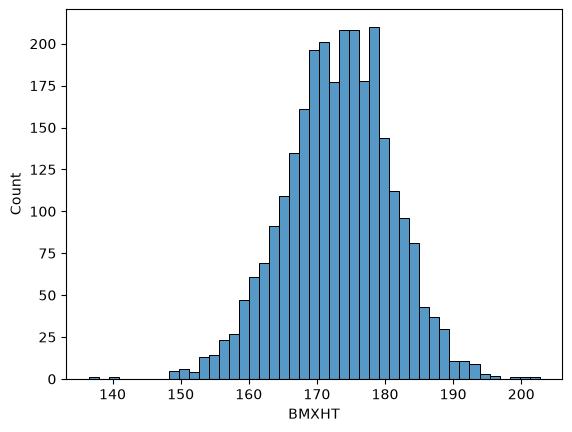

In [27]:
# Histogram for male BMXHT
mal_hei=df.query('RIAGENDR==1')
sns.histplot(data=mal_hei.BMXHT)

<Axes: xlabel='RIAGENDRx', ylabel='BMXHT'>

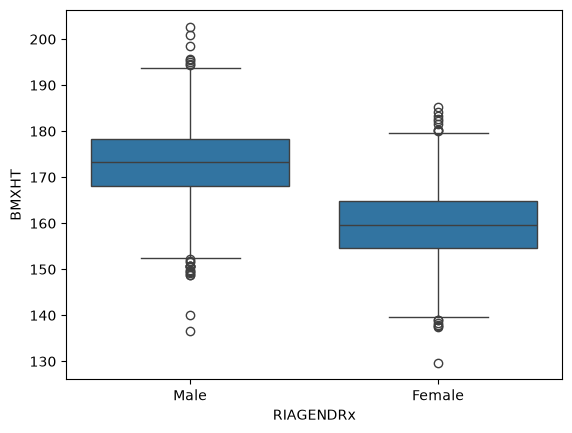

In [30]:
# boxplot of BMXHT by RIAGENDR
sns.boxplot(x='RIAGENDRx',y='BMXHT',data=df)

__Q3c.__ What features (if any) are not represented clearly in the boxplots, and what features (if any) are easier to see in the boxplots than in the histograms?

## Question 4

Make a boxplot showing the distribution of within-subject differences between the first and second systolic blood pressure measurents ([BPXSY1](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm#BPXSY1) and [BPXSY2](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm#BPXSY2)).

https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm

<Axes: >

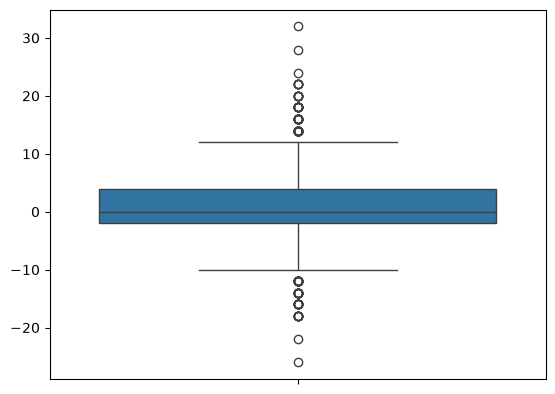

In [31]:
# boxplot of difference  between BPXSY1 and BPXSY2
bp_diff=df['BPXSY1']-df['BPXSY2']
sns.boxplot(data=bp_diff)

__Q4a.__ What proportion of the subjects have a lower SBP on the second reading compared to the first?

In [ ]:
# create a boolean variable that is True if "bp_diff" is positive and False if "bp_diff" is negative
lower_second = (bp_diff.dropna() > 0)

# Booleans are either True or False but...
# internally Python stores True values as 1 and False values as 0...
# so taking the average of a Boolean variable will give us the proportion of 1 values (True values)
print(np.mean(lower_second))

# another way to measure the proportion of True and False values
#print(lower_second.value_counts(normalize=True))

0.45874464518532315


__Q4b.__ Make side-by-side boxplots of the two systolic blood pressure variables.

<Axes: >

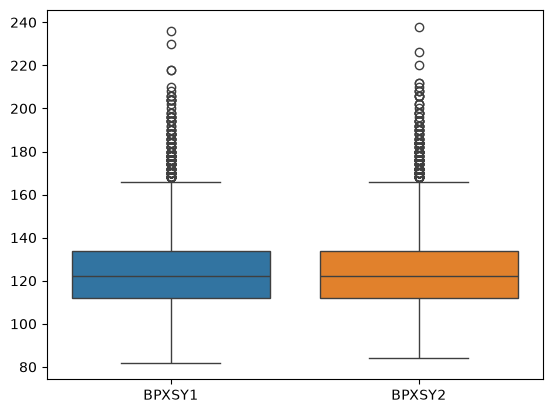

In [33]:
sns.boxplot(data=df.loc[:,['BPXSY1','BPXSY2']])

__Q4c.__ Comment on the systolic blood pressure measurement variation (either BPXSY1 or BPXSY2) and the within-subject difference variation.

In [34]:
# Numerical summaries might also be helpful in this instance
print(df['BPXSY1'].describe(),'\n')
print(df['BPXSY2'].describe(),'\n')
print(bp_diff.describe())

count    5401.000000
mean      125.084614
std        18.480873
min        82.000000
25%       112.000000
50%       122.000000
75%       134.000000
max       236.000000
Name: BPXSY1, dtype: float64 

count    5535.000000
mean      124.783017
std        18.527012
min        84.000000
25%       112.000000
50%       122.000000
75%       134.000000
max       238.000000
Name: BPXSY2, dtype: float64 

count    5369.000000
mean        0.674986
std         5.046465
min       -26.000000
25%        -2.000000
50%         0.000000
75%         4.000000
max        32.000000
dtype: float64


## Question 5

Construct a frequency table of household sizes for people within each educational attainment category (the relevant variable is [DMDEDUC2](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#DMDEDUC2)).

Convert the frequencies to proportions.

https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm

https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html

In [35]:
# frequency (counts) table
pd.crosstab(df['DMDEDUC2'],df['DMDHHSIZ'])

DMDHHSIZ,1,2,3,4,5,6,7
DMDEDUC2,,,,,,,
1.0,72,147,96,87,97,71,85
2.0,75,143,105,98,94,73,55
3.0,181,321,203,192,130,78,81
4.0,245,436,313,274,198,82,73
5.0,195,475,265,226,130,40,35
9.0,0,2,0,0,1,0,0


In [36]:
# Normalize (by row) frequency table
pd.crosstab(df['DMDEDUC2'],df['DMDHHSIZ'],margins=True,normalize='index')

DMDHHSIZ,1,2,3,4,5,6,7
DMDEDUC2,,,,,,,
1.0,0.109924,0.224427,0.146565,0.132824,0.148092,0.108397,0.129771
2.0,0.116641,0.222395,0.163297,0.152411,0.146190,0.113530,0.085537
3.0,0.152614,0.270658,0.171164,0.161889,0.109612,0.065767,0.068297
4.0,0.151141,0.268970,0.193091,0.169031,0.122147,0.050586,0.045034
5.0,0.142753,0.347731,0.193997,0.165447,0.095168,0.029283,0.025622
9.0,0.000000,0.666667,0.000000,0.000000,0.333333,0.000000,0.000000
All,0.140300,0.278407,0.179393,0.160212,0.118743,0.062843,0.060102


__Q5b.__ Restrict the sample to people between 30 and 40 years of age.  Then calculate the median household size for women and men within each level of educational attainment.

In [37]:
# if necessary reload the nhanes csv file to avoid possible data "contamination" from previous work
da = pd.read_csv("nhanes_2015_2016.csv")

In [38]:
# make copy of the dataframe to protect the original
da_mod = da.copy()

# relabel RIAGENDR
rgen = {1: "Male", 2: "Female"}
da_mod["RIAGENDRx"] = da_mod["RIAGENDR"].replace(rgen)

# relabel DMDEDUC2
redu = {1: "1) LT 9", 2: "2) 9 to 11", 3: "3) HS or GED", 4: "4) Some college or AA", 5: "5) College", 7: "7) Refused", 9: "9) Don't know"}
da_mod["DMDEDUC2x"] = da_mod.DMDEDUC2.replace(redu)

# drop the variables that we don't need
da_mod = da_mod[["RIAGENDRx", "RIDAGEYR", "DMDEDUC2x", "DMDHHSIZ"]]

In [39]:
# create a closed interval range from 30 to 40
binrange = pd.interval_range(start=30, end=40, periods=1, closed='both')

# create the 30-40 'bin' variable
da_mod["agegrp"] = pd.cut(da_mod.RIDAGEYR, binrange)

# what does DMDEDUC2x look like?
#print(da_mod.DMDEDUC2x.value_counts())

# drop rare or missing values
da_mod = da_mod.loc[~da_mod.DMDEDUC2x.isin(["7) Refused", "9) Don't know"]), :]

# median by RIAGENDRx and DMDEDUC2x
dx = da_mod.groupby(["agegrp", "RIAGENDRx", "DMDEDUC2x"])["DMDHHSIZ"].median()
print(dx)

# another way to isolate subjects between 30 and 40 years old
#da3040 = da_mod.query('RIDAGEYR >= 30 & RIDAGEYR <= 40').copy()

# median by RIAGENDRx and DMDEDUC2x
#print(da3040.groupby(["RIAGENDRx", "DMDEDUC2x"])["DMDHHSIZ"].median())

agegrp    RIAGENDRx  DMDEDUC2x            
[30, 40]  Female     1) LT 9                  5.0
                     2) 9 to 11               5.0
                     3) HS or GED             5.0
                     4) Some college or AA    4.0
                     5) College               3.0
          Male       1) LT 9                  5.0
                     2) 9 to 11               4.5
                     3) HS or GED             4.0
                     4) Some college or AA    4.0
                     5) College               3.0
Name: DMDHHSIZ, dtype: float64


## Question 6

The participants can be clustered into "masked variance units" (MVU) based on every combination of the variables [SDMVSTRA](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#SDMVSTRA) and [SDMVPSU](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#SDMVPSU).  Calculate the mean age ([RIDAGEYR](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#RIDAGEYR)), height ([BMXHT](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BMX_I.htm#BMXHT)), and BMI ([BMXBMI](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BMX_I.htm#BMXBMI)) for each gender ([RIAGENDR](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#RIAGENDR)), within each MVU. Report the ratio between the largest and smallest mean (e.g. for height) for each gender across the MVUs.

Note: SDMVSTRA and SDMVPSU are not used this way in a real-world analysis. Their intended use within NHANES is for complex variation estimation.

https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.min.html

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.max.html

In [40]:
# if necessary reload the nhanes csv file to avoid possible data "contamination" from previous work
da = pd.read_csv("nhanes_2015_2016.csv")

In [41]:
# make copy of dataframe to protect the original
da_mod=da.copy()

# separate into two dataframes by RAIGENDRx
dam=da_mod.where(da_mod.RIAGENDR==1)
daf=da_mod.where(da_mod.RIAGENDR==2)

# drop the variables that we don't need
dam = dam[["SDMVSTRA", "SDMVPSU", "RIDAGEYR", "BMXHT", "BMXBMI"]]
daf = daf[["SDMVSTRA", "SDMVPSU", "RIDAGEYR", "BMXHT", "BMXBMI"]]

In [43]:
# Analysis for Males

# calculate the mean for RIDAGEYR, BMXHT and BMXBMI for each MVU
da_mean = dam.groupby(['SDMVPSU', 'SDMVSTRA']).mean()


In [46]:
# calculate and print the BMXHT mean ratio
ratio_height_mean = da_mean['BMXHT'].max()/da_mean['BMXHT'].min()
print("Males")
print(round(ratio_height_mean, 3), " (Height)")


Males
1.045  (Height)


In [47]:
# calculate and print the RIDAGEYR mean ratio
ratio_age_mean = da_mean['RIDAGEYR'].max()/da_mean['RIDAGEYR'].min()
print(round(ratio_age_mean, 3), " (Age)")


1.311  (Age)


In [48]:
# calculate and print the BMXBMI mean ratio
ratio_bmi_mean = da_mean['BMXBMI'].max()/da_mean['BMXBMI'].min()
print(round(ratio_bmi_mean, 3), " (BMI)")


1.233  (BMI)


In [49]:
# calculate the mean for RIDAGEYR, BMXHT and BMXBMI across MVUs
da_mean = daf.groupby(['SDMVPSU', 'SDMVSTRA']).mean()

# calculate and print the BMXHT mean ratio
ratio_height_mean = da_mean['BMXHT'].max()/da_mean['BMXHT'].min()
print("\nFemales")
print(round(ratio_height_mean, 3), " (Height)")

# calculate and print the RIDAGEYR rmean atio
ratio_age_mean = da_mean['RIDAGEYR'].max()/da_mean['RIDAGEYR'].min()
print(round(ratio_age_mean, 3), " (Age)")

# calculate and print the BMXBMI mean ratio
ratio_bmi_mean = da_mean['BMXBMI'].max()/da_mean['BMXBMI'].min()
print(round(ratio_bmi_mean, 3), " (BMI)")


Females
1.048  (Height)
1.308  (Age)
1.246  (BMI)


__Q6a.__ Comment on the extent to which mean age, height, and BMI vary across the MVUs for males and females.

__Q6b.__ Calculate the inter-quartile range (IQR) for age, height, and BMI for each gender and each MVU.  Report the ratio between the largest and smallest IQR across the MVUs.

https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.quantile.html


In [50]:
# Males

# calculate the 2nd and 3rd quintiles for RIDAGEYR, BMXHT and BMXBMI for each MVU
da_q3 = dam.groupby(['SDMVPSU', 'SDMVSTRA']).quantile(.75, numeric_only=True)
da_q1 = dam.groupby(['SDMVPSU', 'SDMVSTRA']).quantile(.25, numeric_only=True)

# calculate the IQR for RIDAGEYR, BMXHT and BMXBMI
da_iqr = da_q3 - da_q1

# calculate and print the BMXHT iqr ratio
ratio_height_iqr = da_iqr['BMXHT'].max()/da_iqr['BMXHT'].min()
print("Males")
print(round(ratio_height_iqr, 3), " (Height)")

# calculate and print the RIDAGEYR iqr ratio
ratio_age_iqr = da_iqr['RIDAGEYR'].max()/da_iqr['RIDAGEYR'].min()
print(round(ratio_age_iqr, 3), " (Age)")

# calculate and print the BMXBMI iqr ratio
ratio_bmi_iqr = da_iqr['BMXBMI'].max()/da_iqr['BMXBMI'].min()
print(round(ratio_bmi_iqr, 3), " (BMI)")

Males
1.587  (Height)
1.831  (Age)
2.341  (BMI)


In [51]:
# Females

# calculate the 2nd and 3rd quintiles for RIDAGEYR, BMXHT and BMXBMI across MVUs
da_q3 = daf.groupby(['SDMVPSU', 'SDMVSTRA']).quantile(.75, numeric_only=True)
da_q1 = daf.groupby(['SDMVPSU', 'SDMVSTRA']).quantile(.25, numeric_only=True)

# calculate the IQR for RIDAGEYR, BMXHT and BMXBMI
da_iqr = da_q3 - da_q1

# calculate and print the BMXHT iqr ratio
ratio_height_iqr = da_iqr['BMXHT'].max()/da_iqr['BMXHT'].min()
print("\nFemales")
print(round(ratio_height_iqr, 3), " (Height)")

# calculate and print the RIDAGEYR iqr ratio
ratio_age_iqr = da_iqr['RIDAGEYR'].max()/da_iqr['RIDAGEYR'].min()
print(round(ratio_age_iqr, 3), " (Age)")

# calculate and print the BMXBMI iqr ratio
ratio_bmi_iqr = da_iqr['BMXBMI'].max()/da_iqr['BMXBMI'].min()
print(round(ratio_bmi_iqr, 3), " (BMI)")



Females
1.587  (Height)
1.625  (Age)
1.516  (BMI)


__Q6c.__ Comment on the extent to which the IQR for age, height, and BMI vary across the MVUs for males and females.